In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Iterable

In [3]:
import pandas as pd

# Leggi tutto come stringa (per ora)
with open("test_noOpt_.txt", "r") as f:
    lines = f.readlines()

# Processa ogni riga
data = []
for line in lines:
    parts = line.split()            # dividi per spazi
    tipo_coda, metodo, thread = parts[:3]   # prime 3 colonne
    valori = list(map(int, parts[3:]))      # tutti i restanti valori in lista
    data.append([tipo_coda, metodo, thread, valori])

# Crea DataFrame
df = pd.DataFrame(data, columns=["tipo_coda", "metodo", "thread", "valori"])

# Visualizza
print(df.head())

  tipo_coda      metodo   thread                                valori
0     deque  Push_Front  multi_1  [78117, 49489, 105159, 47802, 51246]
1     deque   Push_Back  multi_1   [49494, 46490, 81354, 49556, 52288]
2     deque   Pop_Front  multi_1   [45154, 41896, 93174, 42591, 48144]
3     deque    Pop_Back  multi_1   [41549, 55884, 42414, 43117, 48480]
4   relaxed  Push_Front  multi_1   [30314, 32154, 42754, 39022, 31225]


## sigle thread

In [4]:
def plot(data_list, title, labels):

    fig, ax = plt.subplots(figsize=[8, 8])

    boxes = []
    ticks = []

    for i in range(0,len(data_list)):
        boxes.append(data_list[i])
        ticks.append(labels[i])

    bplot = ax.boxplot(boxes, showfliers=False)
    # Etichette per gli assi
    ax.set_xticks(range(1,len(labels)+1),ticks)
    ax.set(ylabel = 'Microseconds')
    ax.set(title = title)
    ax.set_yscale('log')

    for median in bplot['medians']:
        median.set_color('red')
    plt.figtext(0.78, 0.9, f"runs: {len(data_list[0])}\nn_elem: {n_elem}", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))
    plt.show()

In [21]:
code = ["deque","relaxed","deferred","blocking"]
metodi = ["Push_Front","Push_Back","Pop_Front","Pop_Back","random"]
thread = ["single", "multi_1", "multi_2","multi_4", "multi_8"]

for c in code:
    for m in metodi:
        for t in thread:
            subset = df[(df["tipo_coda"]==c) & (df["metodo"]==m) & (df["thread"]==t)]
            if not subset.empty:
                valori = subset.iloc[0]["valori"]
                # Crea variabile dinamica
                nome_var = f"{c}_{m}_{t}"
                globals()[nome_var] = valori


pop back

=== Pop_Back Single Thread ===
deque: 42214.0
blocking: 47407.0
deferred: 47604.0
relaxed: 41610.0


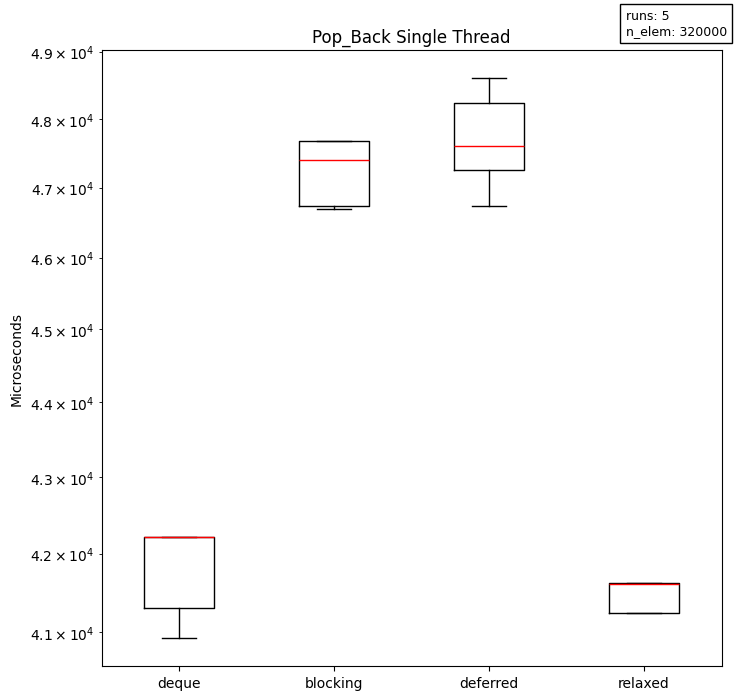


=== Pop_Front Single Thread ===
deque: 42079.0
blocking: 47571.0
deferred: 47805.0
relaxed: 41505.0


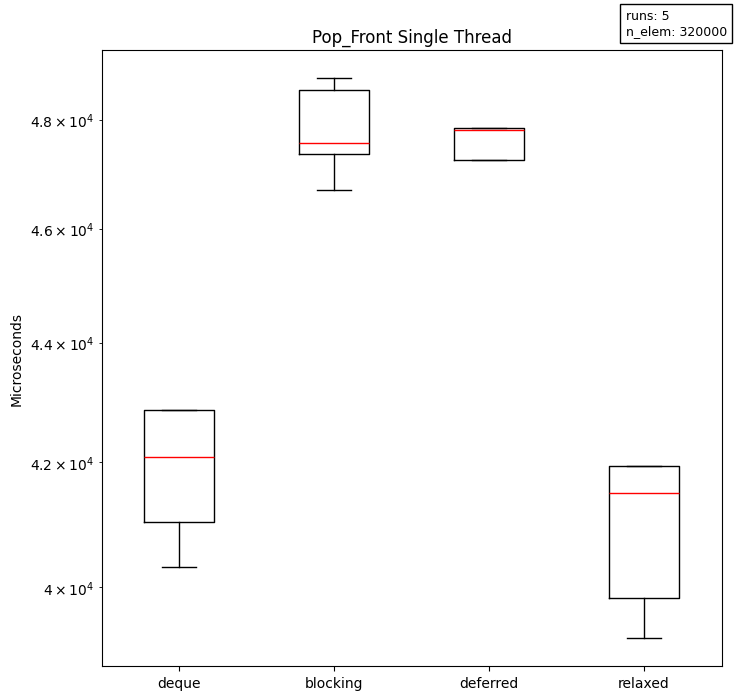


=== Push_Back Single Thread ===
deque: 46963.0
blocking: 36711.0
deferred: 36412.0
relaxed: 30783.0


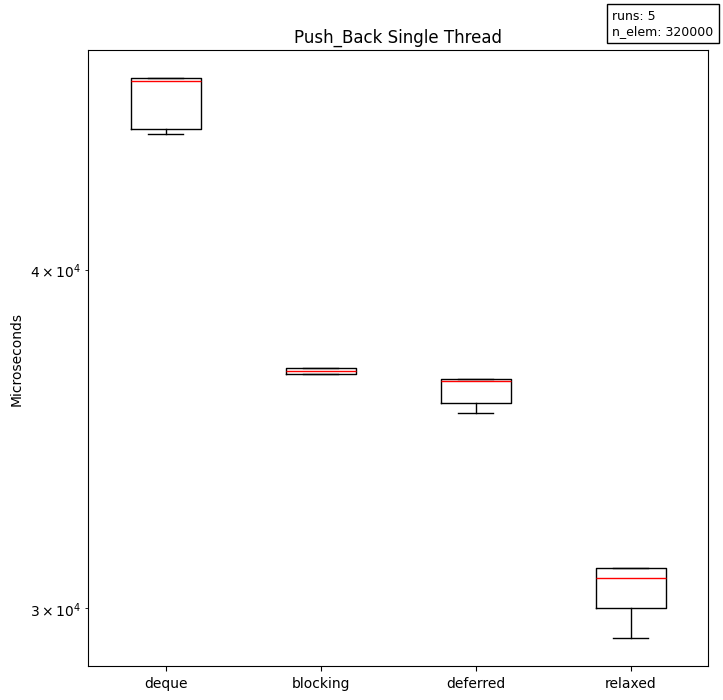


=== Push_Front Single Thread ===
deque: 50337.0
blocking: 36304.0
deferred: 36482.0
relaxed: 31115.0


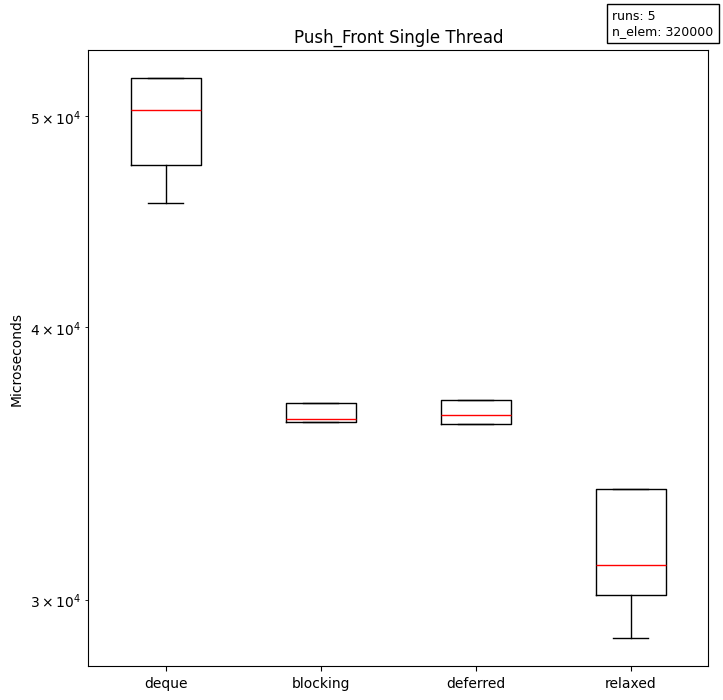

In [ ]:
# dati test
nomi = ["deque", "blocking", "deferred", "relaxed"]

# ===================== DATI SINGLE THREAD =====================
# POP_BACK per thread single
dati_pop_back_single = [
    deque_Pop_Back_single,
    blocking_Pop_Back_single,
    deferred_Pop_Back_single,
    relaxed_Pop_Back_single
]

# POP_FRONT per thread single
dati_pop_front_single = [
    deque_Pop_Front_single,
    blocking_Pop_Front_single,
    deferred_Pop_Front_single,
    relaxed_Pop_Front_single
]

# PUSH_BACK per thread single
dati_push_back_single = [
    deque_Push_Back_single,
    blocking_Push_Back_single,
    deferred_Push_Back_single,
    relaxed_Push_Back_single
]

# PUSH_FRONT per thread single
dati_push_front_single = [
    deque_Push_Front_single,
    blocking_Push_Front_single,
    deferred_Push_Front_single,
    relaxed_Push_Front_single
]

n_elem = 128000

# ===================== Calcola e stampa le mediane =====================
print("=== Pop_Back Single Thread ===")
for nome, dati in zip(nomi, dati_pop_back_single):
    mediana = np.median(dati)
    print(f"{nome}: {mediana}")
plot(dati_pop_back_single, "Pop_Back Single Thread", nomi)

print("\n=== Pop_Front Single Thread ===")
for nome, dati in zip(nomi, dati_pop_front_single):
    mediana = np.median(dati)
    print(f"{nome}: {mediana}")
plot(dati_pop_front_single, "Pop_Front Single Thread", nomi)

print("\n=== Push_Back Single Thread ===")
for nome, dati in zip(nomi, dati_push_back_single):
    mediana = np.median(dati)
    print(f"{nome}: {mediana}")
plot(dati_push_back_single, "Push_Back Single Thread", nomi)

print("\n=== Push_Front Single Thread ===")
for nome, dati in zip(nomi, dati_push_front_single):
    mediana = np.median(dati)
    print(f"{nome}: {mediana}")
plot(dati_push_front_single, "Push_Front Single Thread", nomi)


## multithread

In [12]:
n_thread = [1,2,4,8] #hard code in .sh copialo da li
n_elem = 128000 ##hard code quando fai run di fie.sh

In [13]:
def multi_plot(data1, data2, data3, data4, title, labels, n_threads):
    fig, ax = plt.subplots(figsize=[10, 10])

    boxes = []
    colors = []
    group_positions = []  # Per le etichette centrate

    color_map = ["peachpuff", "orange", "yellow", "blue"]

    for i in range(len(n_threads)):
        boxes.extend([data1[i], data2[i], data3[i], data4[i]])
        colors.extend(color_map)
        # Ogni gruppo di 4 box parte alla posizione 4*i+1 → il centro è +1.5
        group_center = 4 * i + 2.5
        group_positions.append(group_center)

    # Crea boxplot
    bplot = ax.boxplot(boxes, showfliers=False, patch_artist=True)

    # Colori per ogni box
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

    # Etichette centrate per ogni gruppo
    ax.set_xticks(group_positions)
    ax.set_xticklabels([str(n) for n in n_threads])

    # Etichette e titolo
    ax.set_ylabel('Microseconds')
    ax.set_xlabel('n_threads')
    ax.set_title(title, loc='left')
    ax.set_yscale('log')
    
    # Legenda (usiamo solo il primo gruppo per i colori)
    legend_handles = [bplot["boxes"][i] for i in range(4)]
    ax.legend(legend_handles, labels, loc='upper right')

    # Mediane in rosso
    for median in bplot['medians']:
        median.set_color('red')

    plt.figtext(0.78, 0.98, f"runs: {len(data1[0])}\nn_elem: {n_elem}", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))

    plt.tight_layout()
    plt.show()

    # ======= Calcolo e stampa delle mediane numeriche =======
    print(f"\n=== Median values for {title} ===")
    medians = [np.median(b) for b in boxes]
    
    for i, n in enumerate(n_threads):
        print(f"\nThreads = {n}")
        for j, label in enumerate(labels):
            idx = i * 4 + j
            print(f"  {label:>12}: {medians[idx]:.2f}")


In [14]:
# ===================== DEQUE =====================
dati_deque_Push_Front_multi = [
    deque_Push_Front_multi_1,
    deque_Push_Front_multi_2,
    deque_Push_Front_multi_4,
    deque_Push_Front_multi_8
]

dati_deque_Push_Back_multi = [
    deque_Push_Back_multi_1,
    deque_Push_Back_multi_2,
    deque_Push_Back_multi_4,
    deque_Push_Back_multi_8
]

dati_deque_Pop_Front_multi = [
    deque_Pop_Front_multi_1,
    deque_Pop_Front_multi_2,
    deque_Pop_Front_multi_4,
    deque_Pop_Front_multi_8
]

dati_deque_Pop_Back_multi = [
    deque_Pop_Back_multi_1,
    deque_Pop_Back_multi_2,
    deque_Pop_Back_multi_4,
    deque_Pop_Back_multi_8
]

# ===================== RELAXED =====================
dati_relaxed_Push_Front_multi = [
    relaxed_Push_Front_multi_1,
    relaxed_Push_Front_multi_2,
    relaxed_Push_Front_multi_4,
    relaxed_Push_Front_multi_8
]

dati_relaxed_Push_Back_multi = [
    relaxed_Push_Back_multi_1,
    relaxed_Push_Back_multi_2,
    relaxed_Push_Back_multi_4,
    relaxed_Push_Back_multi_8
]

dati_relaxed_Pop_Front_multi = [
    relaxed_Pop_Front_multi_1,
    relaxed_Pop_Front_multi_2,
    relaxed_Pop_Front_multi_4,
    relaxed_Pop_Front_multi_8
]

dati_relaxed_Pop_Back_multi = [
    relaxed_Pop_Back_multi_1,
    relaxed_Pop_Back_multi_2,
    relaxed_Pop_Back_multi_4,
    relaxed_Pop_Back_multi_8
]

# ===================== DEFERRED =====================
dati_deferred_Push_Front_multi = [
    deferred_Push_Front_multi_1,
    deferred_Push_Front_multi_2,
    deferred_Push_Front_multi_4,
    deferred_Push_Front_multi_8
]

dati_deferred_Push_Back_multi = [
    deferred_Push_Back_multi_1,
    deferred_Push_Back_multi_2,
    deferred_Push_Back_multi_4,
    deferred_Push_Back_multi_8
]

dati_deferred_Pop_Front_multi = [
    deferred_Pop_Front_multi_1,
    deferred_Pop_Front_multi_2,
    deferred_Pop_Front_multi_4,
    deferred_Pop_Front_multi_8
]

dati_deferred_Pop_Back_multi = [
    deferred_Pop_Back_multi_1,
    deferred_Pop_Back_multi_2,
    deferred_Pop_Back_multi_4,
    deferred_Pop_Back_multi_8
]

# ===================== BLOCKING =====================
dati_blocking_Push_Front_multi = [
    blocking_Push_Front_multi_1,
    blocking_Push_Front_multi_2,
    blocking_Push_Front_multi_4,
    blocking_Push_Front_multi_8
]

dati_blocking_Push_Back_multi = [
    blocking_Push_Back_multi_1,
    blocking_Push_Back_multi_2,
    blocking_Push_Back_multi_4,
    blocking_Push_Back_multi_8
]

dati_blocking_Pop_Front_multi = [
    blocking_Pop_Front_multi_1,
    blocking_Pop_Front_multi_2,
    blocking_Pop_Front_multi_4,
    blocking_Pop_Front_multi_8
]

dati_blocking_Pop_Back_multi = [
    blocking_Pop_Back_multi_1,
    blocking_Pop_Back_multi_2,
    blocking_Pop_Back_multi_4,
    blocking_Pop_Back_multi_8
]



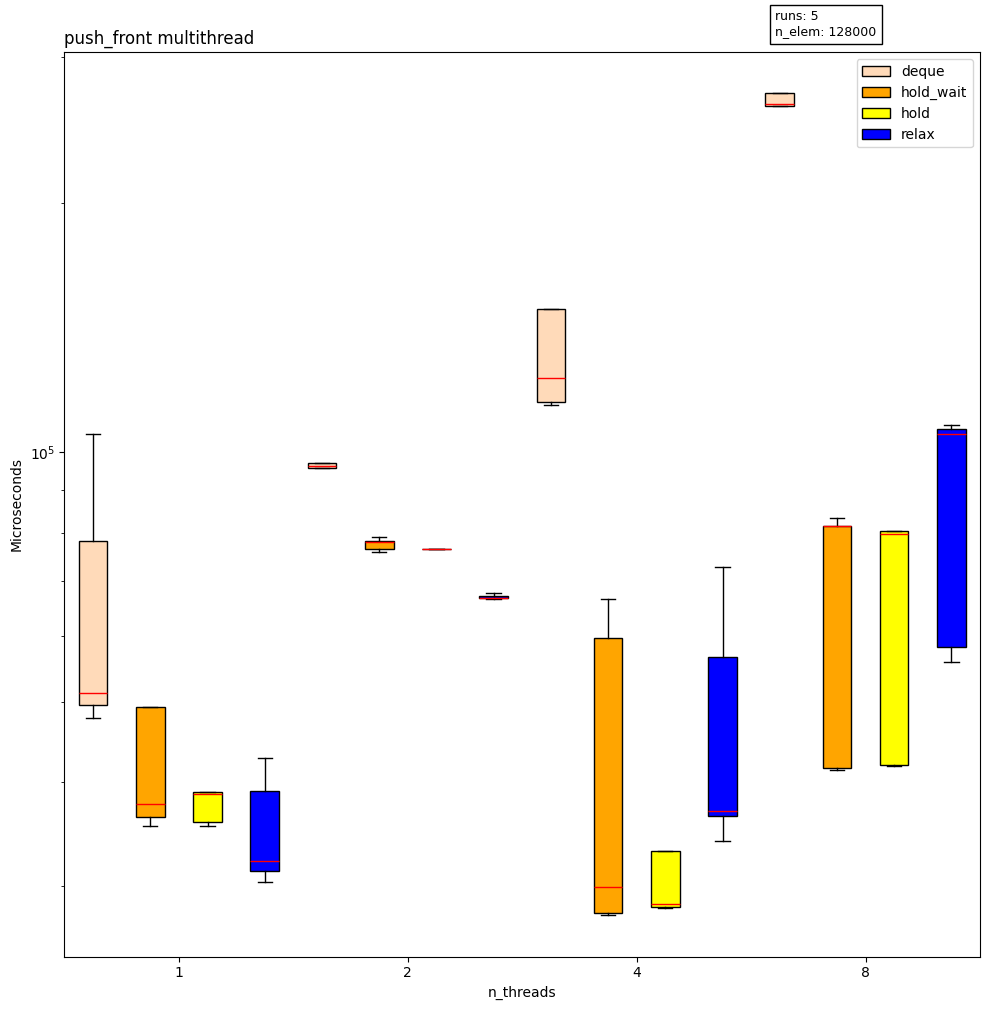


=== Median values for push_front multithread ===

Threads = 1
         deque: 51246.00
     hold_wait: 37632.00
          hold: 38649.00
         relax: 32154.00

Threads = 2
         deque: 96362.00
     hold_wait: 77878.00
          hold: 76425.00
         relax: 66696.00

Threads = 4
         deque: 123008.00
     hold_wait: 29912.00
          hold: 28517.00
         relax: 36913.00

Threads = 8
         deque: 263019.00
     hold_wait: 81461.00
          hold: 79708.00
         relax: 105224.00


In [15]:
multi_plot(dati_deque_Push_Front_multi, dati_blocking_Push_Front_multi, dati_deferred_Push_Front_multi,dati_relaxed_Push_Front_multi , "push_front multithread", ["deque","hold_wait","hold","relax"], n_thread)

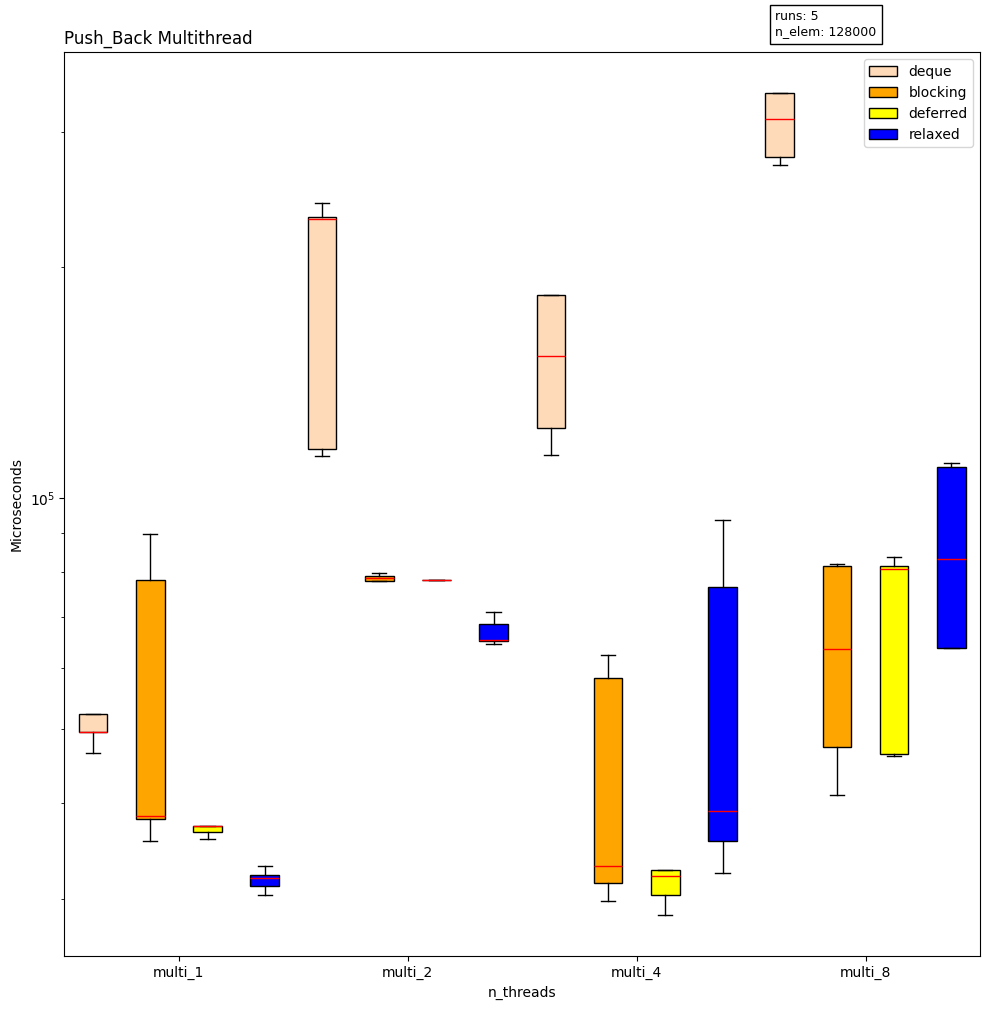


=== Median values for Push_Back Multithread ===

Threads = multi_1
         deque: 49556.00
      blocking: 38456.00
      deferred: 37315.00
       relaxed: 31909.00

Threads = multi_2
         deque: 231198.00
      blocking: 78544.00
      deferred: 78166.00
       relaxed: 65356.00

Threads = multi_4
         deque: 153385.00
      blocking: 33085.00
      deferred: 32111.00
       relaxed: 39062.00

Threads = multi_8
         deque: 312472.00
      blocking: 63579.00
      deferred: 80893.00
       relaxed: 83190.00


In [19]:
multi_plot(
    dati_deque_Push_Back_multi,
    dati_blocking_Push_Back_multi,
    dati_deferred_Push_Back_multi,
    dati_relaxed_Push_Back_multi,
    "Push_Back Multithread",
    ["deque","blocking","deferred","relaxed"],
    ["multi_1", "multi_2", "multi_4", "multi_8"]
)

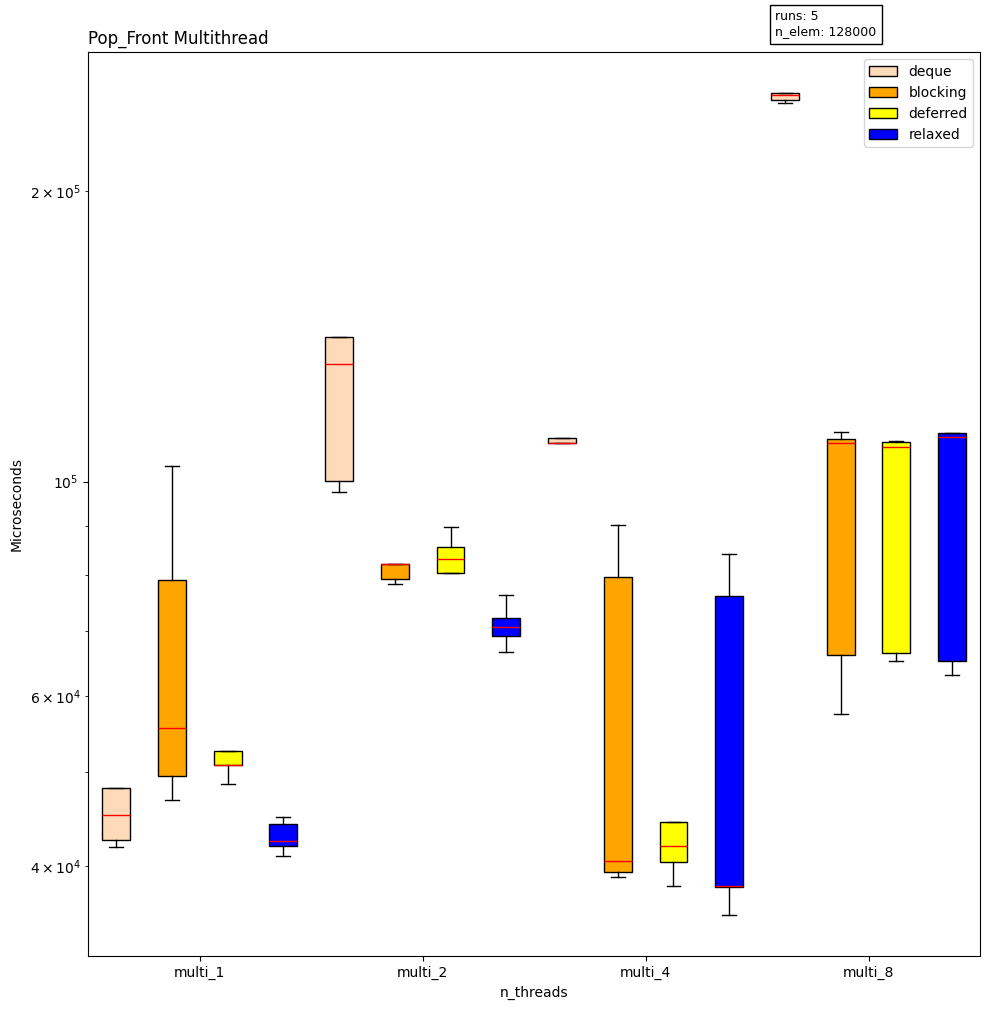


=== Median values for Pop_Front Multithread ===

Threads = multi_1
         deque: 45154.00
      blocking: 55531.00
      deferred: 50932.00
       relaxed: 42433.00

Threads = multi_2
         deque: 132378.00
      blocking: 82217.00
      deferred: 83169.00
       relaxed: 70730.00

Threads = multi_4
         deque: 109734.00
      blocking: 40499.00
      deferred: 41981.00
       relaxed: 38124.00

Threads = multi_8
         deque: 251344.00
      blocking: 109631.00
      deferred: 108659.00
       relaxed: 111123.00


In [18]:
multi_plot(
    dati_deque_Pop_Front_multi,
    dati_blocking_Pop_Front_multi,
    dati_deferred_Pop_Front_multi,
    dati_relaxed_Pop_Front_multi,
    "Pop_Front Multithread",
    ["deque","blocking","deferred","relaxed"],
    ["multi_1", "multi_2", "multi_4", "multi_8"]
)

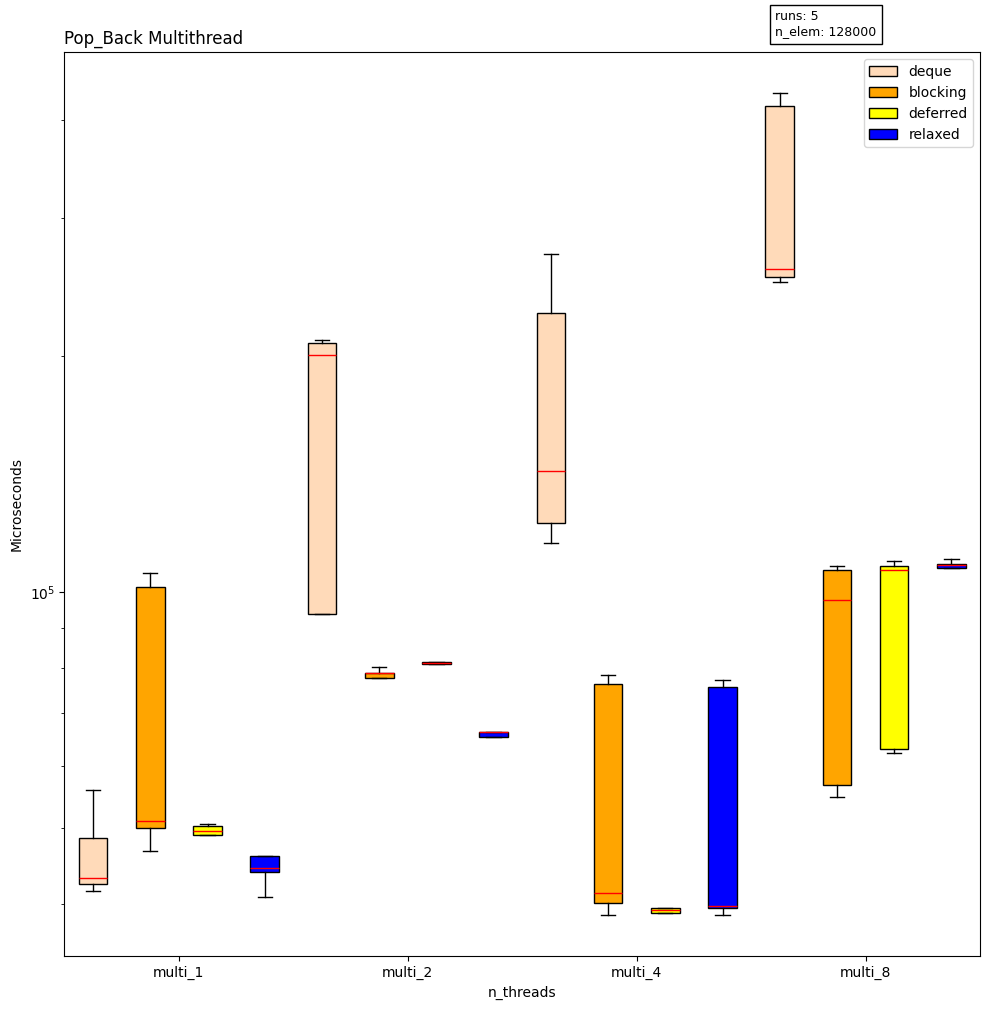


=== Median values for Pop_Back Multithread ===

Threads = multi_1
         deque: 43117.00
      blocking: 51082.00
      deferred: 49503.00
       relaxed: 44455.00

Threads = multi_2
         deque: 200652.00
      blocking: 78673.00
      deferred: 81127.00
       relaxed: 66217.00

Threads = multi_4
         deque: 142398.00
      blocking: 41281.00
      deferred: 39220.00
       relaxed: 39792.00

Threads = multi_8
         deque: 258090.00
      blocking: 97474.00
      deferred: 106696.00
       relaxed: 108024.00


In [17]:
multi_plot(
    dati_deque_Pop_Back_multi,
    dati_blocking_Pop_Back_multi,
    dati_deferred_Pop_Back_multi,
    dati_relaxed_Pop_Back_multi,
    "Pop_Back Multithread",
    ["deque","blocking","deferred","relaxed"],
    ["multi_1", "multi_2", "multi_4", "multi_8"]
)

## Random

In [23]:

# ===================== DEQUE =====================
dati_deque_random_multi = [
    deque_random_multi_1,
    deque_random_multi_2,
    deque_random_multi_4,
    deque_random_multi_8
]

# ===================== RELAXED =====================
dati_relaxed_random_multi = [
    relaxed_random_multi_1,
    relaxed_random_multi_2,
    relaxed_random_multi_4,
    relaxed_random_multi_8
]

# ===================== DEFERRED =====================
dati_deferred_random_multi = [
    deferred_random_multi_1,
    deferred_random_multi_2,
    deferred_random_multi_4,
    deferred_random_multi_8
]

# ===================== BLOCKING =====================
dati_blocking_random_multi = [
    blocking_random_multi_1,
    blocking_random_multi_2,
    blocking_random_multi_4,
    blocking_random_multi_8
]


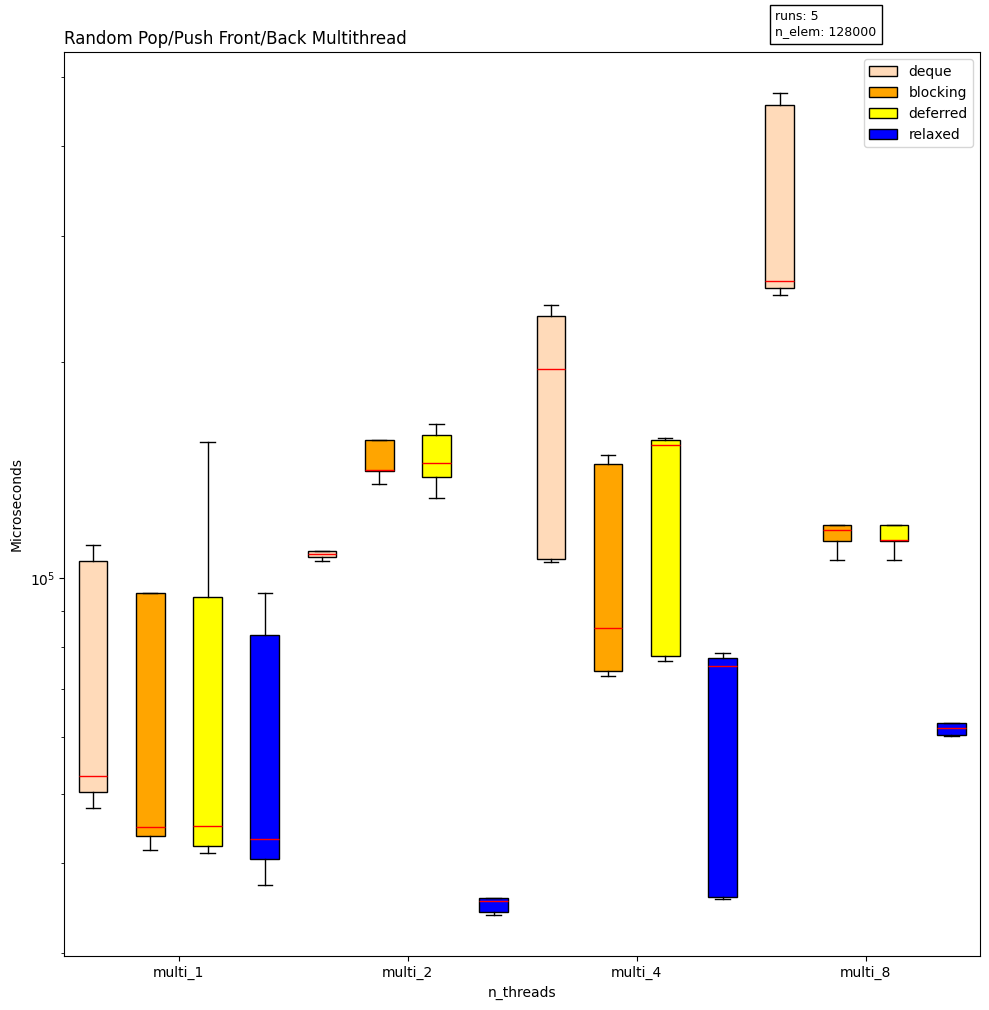


=== Median values for Random Pop/Push Front/Back Multithread ===

Threads = multi_1
         deque: 52983.00
      blocking: 44967.00
      deferred: 45040.00
       relaxed: 43261.00

Threads = multi_2
         deque: 107793.00
      blocking: 141513.00
      deferred: 144544.00
       relaxed: 35379.00

Threads = multi_4
         deque: 195417.00
      blocking: 85140.00
      deferred: 153357.00
       relaxed: 75276.00

Threads = multi_8
         deque: 259515.00
      blocking: 116714.00
      deferred: 112987.00
       relaxed: 61781.00


In [25]:
multi_plot(
    dati_deque_random_multi,
    dati_blocking_random_multi,
    dati_deferred_random_multi,
    dati_relaxed_random_multi,
    "Random Pop/Push Front/Back Multithread",
    ["deque","blocking","deferred","relaxed"],
    ["multi_1", "multi_2", "multi_4", "multi_8"]
)
